In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_parquet("../data/processed/train.parquet")
val = pd.read_parquet("../data/processed/val.parquet")
test = pd.read_parquet("../data/processed/test.parquet")

print("Train size:", len(train))
print("Validation size:", len(val))
print("Test size:", len(test))

Train size: 53531
Validation size: 7793
Test size: 15160


In [1]:
import sys
print(sys.executable)

/Users/karthiksekar/disaster_decision_support/venv/bin/python


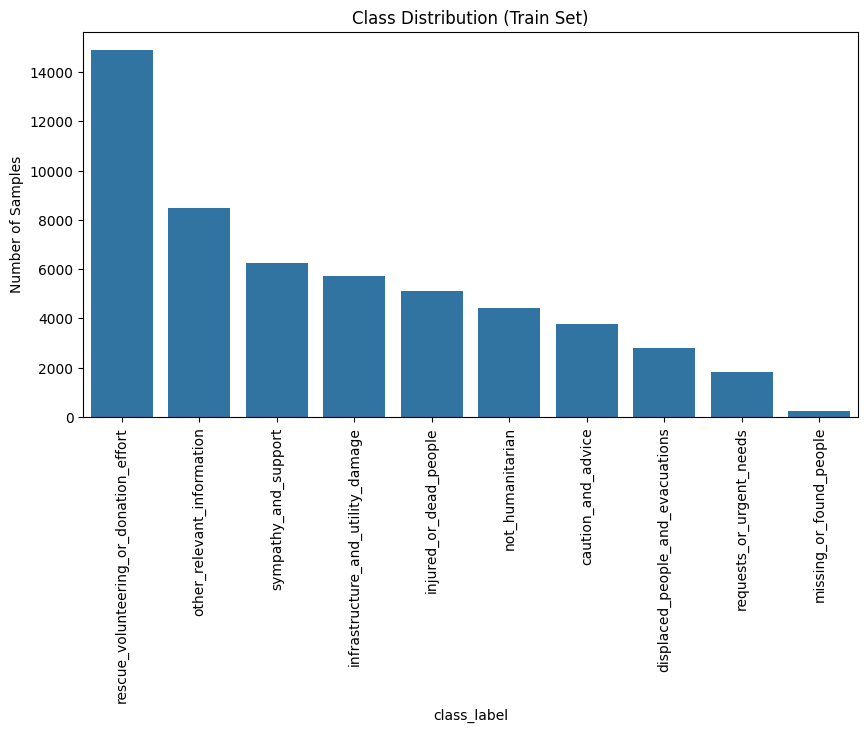

class_label
rescue_volunteering_or_donation_effort    14891
other_relevant_information                 8501
sympathy_and_support                       6250
infrastructure_and_utility_damage          5715
injured_or_dead_people                     5110
not_humanitarian                           4407
caution_and_advice                         3774
displaced_people_and_evacuations           2800
requests_or_urgent_needs                   1833
missing_or_found_people                     250
Name: count, dtype: int64

In [2]:
class_counts = train["class_label"].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(rotation=90)
plt.title("Class Distribution (Train Set)")
plt.ylabel("Number of Samples")
plt.show()

class_counts

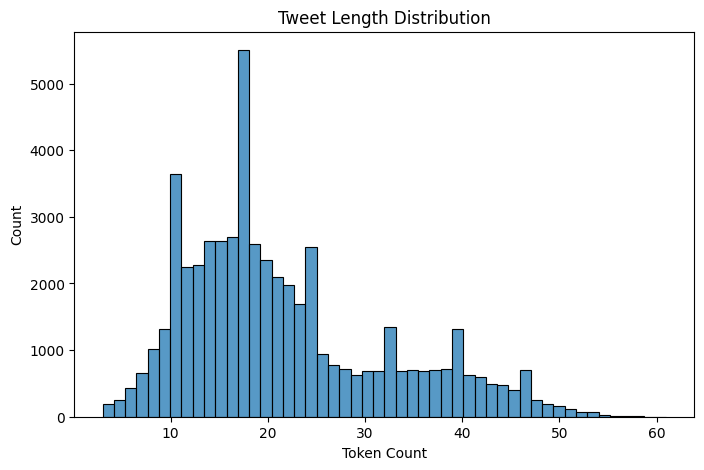

Max length: 61
Mean length: 21.674805253030954


In [3]:
train["token_length"] = train["tweet_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(train["token_length"], bins=50)
plt.title("Tweet Length Distribution")
plt.xlabel("Token Count")
plt.show()

print("Max length:", train["token_length"].max())
print("Mean length:", train["token_length"].mean())

In [4]:
low_info_count = train["low_info"].sum()
print("Low information tweets:", low_info_count)
print("Percentage:", (low_info_count / len(train)) * 100)

Low information tweets: 0
Percentage: 0.0


Class Imbalance Handling

In [7]:
import torch
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train["label"]  # numerical labels column

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

class_weights = class_weights / class_weights.mean()

print(class_weights)

tensor([0.4337, 0.5845, 0.2864, 0.3203, 6.5466, 0.3714, 0.1925, 0.8929, 0.1099,
        0.2619])


In [8]:
torch.save(class_weights, "../data/processed/class_weights.pt")